In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
df = pd.read_csv("/content/wine_dataset.csv")

In [ ]:
pd.set_option('display.max_columns', None)
display(df.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


In [ ]:
target_percentage = df['target'].value_counts(normalize=True) * 100
print("Percentage of values in 'target' column:")
print(target_percentage)

highest_percentage_value = target_percentage.idxmax()
highest_percentage = target_percentage.max()
print(f"\nThe value with the highest percentage in 'target' column is: {highest_percentage_value} with {highest_percentage:.2f}%")

Percentage of values in 'target' column:
target
1    39.887640
0    33.146067
2    26.966292
Name: proportion, dtype: float64

The value with the highest percentage in 'target' column is: 1 with 39.89%


## 1. Check for Missing Data

In [ ]:
print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


## 2. Calculate Mean, Median, and Other Descriptive Statistics

In [ ]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## 3. General Data Investigation and Outlier Detection

To identify anything suspicious, it's good to check data types, unique values, and visualize distributions. Here are some methods:

### Data Types and Non-Null Counts

In [ ]:
print("DataFrame Information (data types and non-null counts):")
df.info()

DataFrame Information (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    int64  
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline 

### Check Unique Values for Categorical Columns (if any)

In [ ]:
print("Unique values for potential categorical columns:")
for col in df.columns:
    if df[col].nunique() < 20: # Arbitrary threshold to consider a column potentially categorical
        print(f"\nColumn '{col}' unique values:")
        print(df[col].unique())

Unique values for potential categorical columns:

Column 'target' unique values:
[0 1 2]


### Visualize Distributions for Numerical Columns
Histograms and box plots can quickly reveal anomalies, skewness, and outliers.

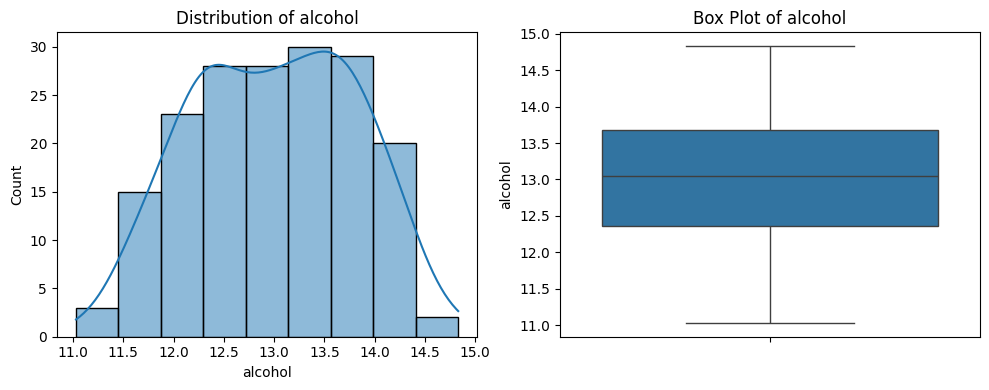

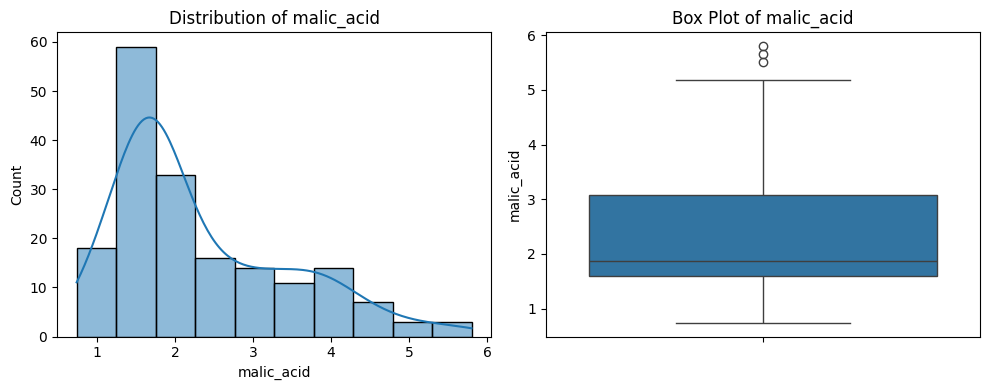

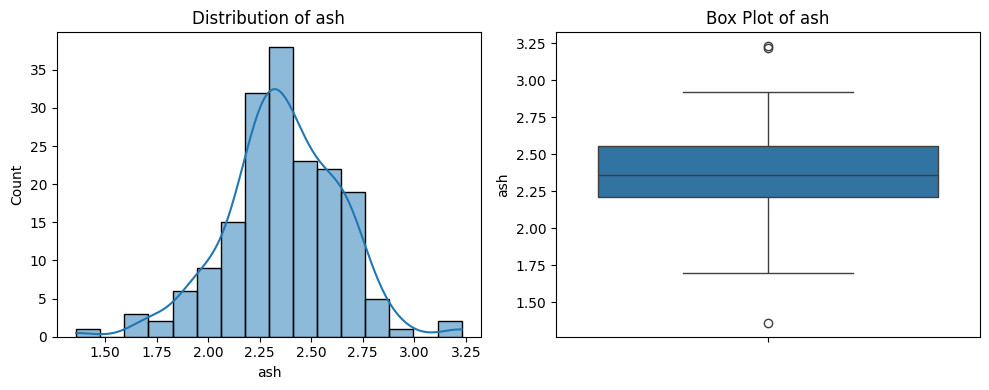

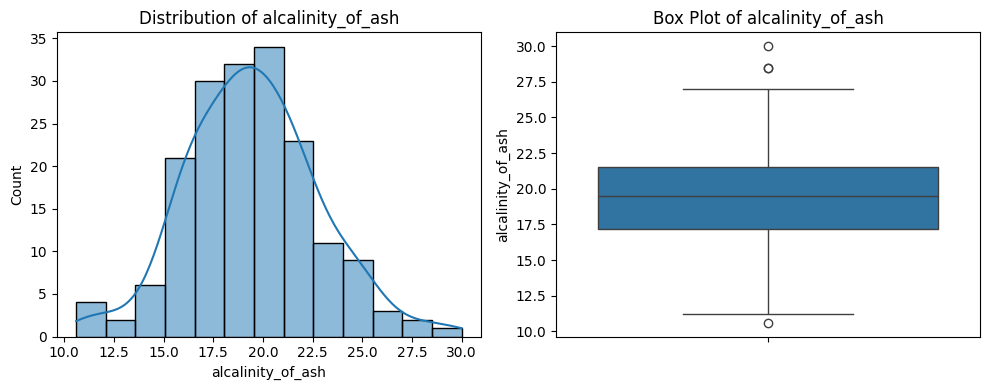

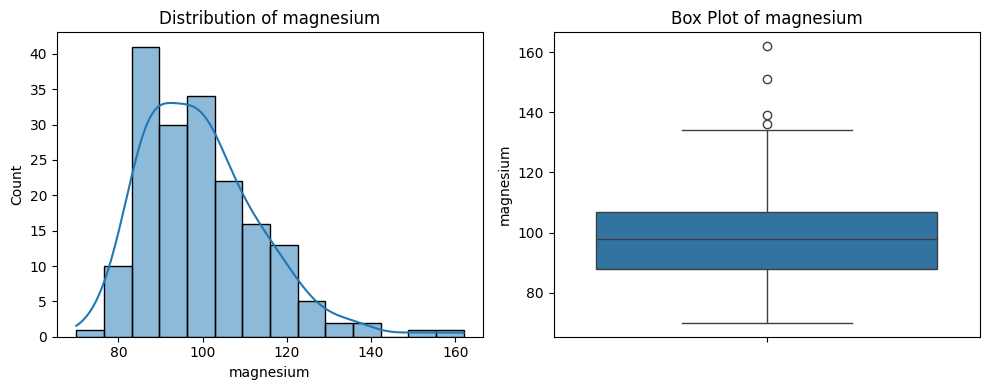

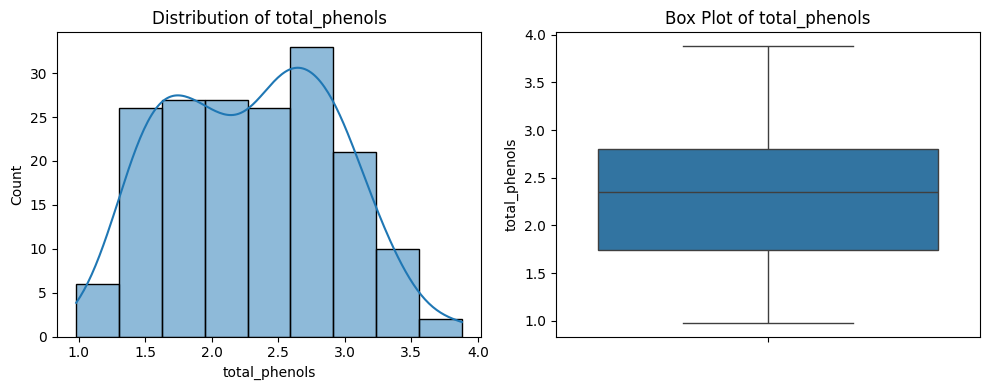

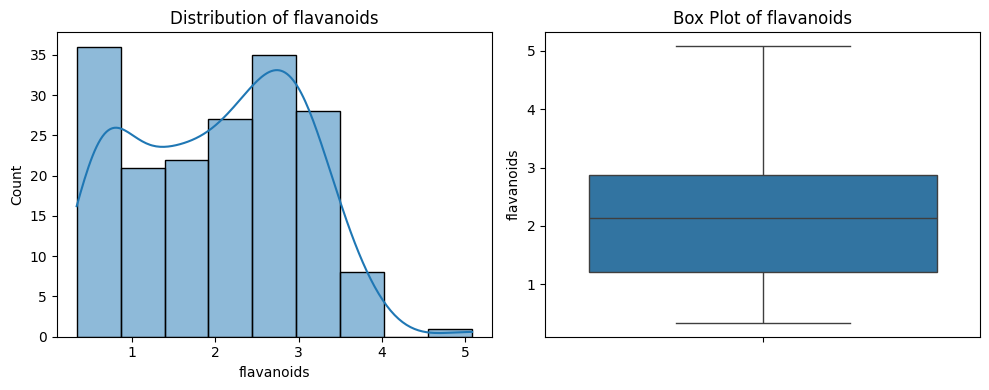

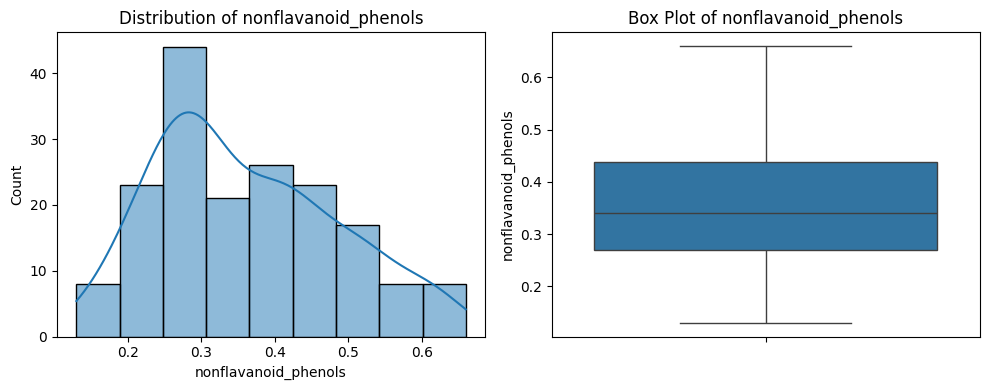

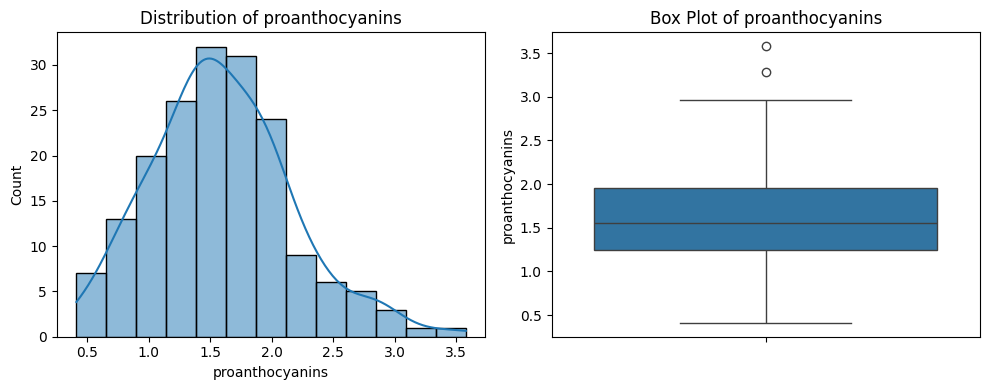

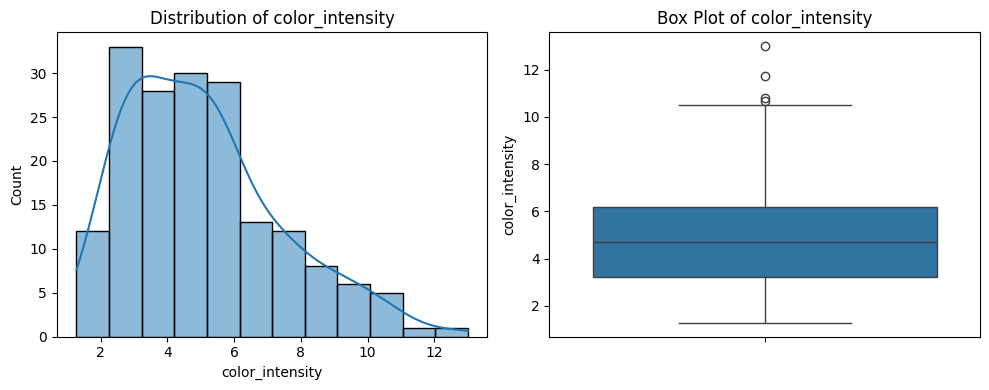

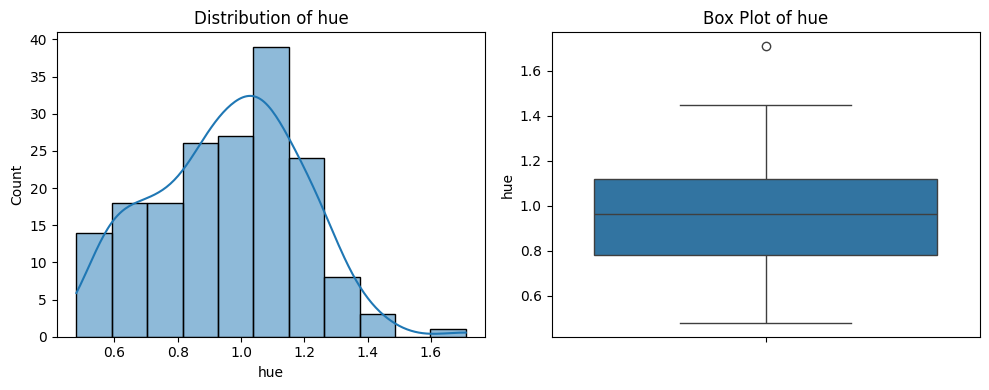

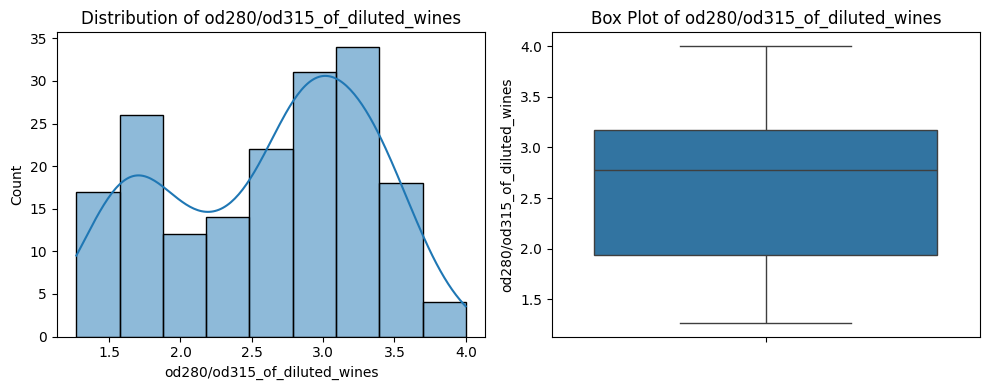

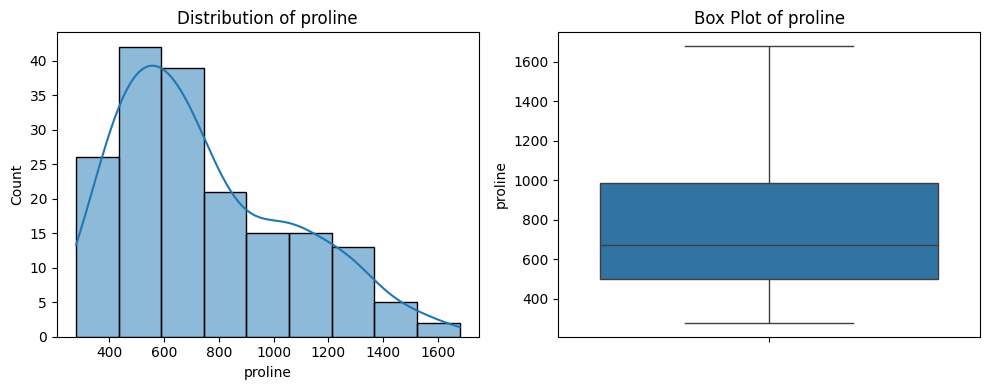

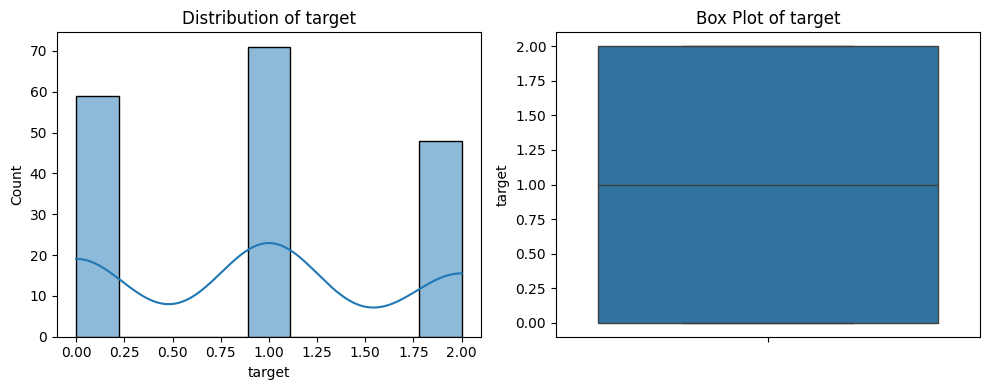

In [ ]:
for column in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.tight_layout()
    plt.show()

### Outlier Detection (using IQR method)

The Interquartile Range (IQR) method is a common way to detect outliers. Values below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` are considered outliers.

In [ ]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

print("Outliers detected using IQR method (if any):")
for column in df.select_dtypes(include=np.number).columns:
    outliers = find_outliers_iqr(df, column)
    if not outliers.empty:
        print(f"\nColumn '{column}' has {len(outliers)} outliers:")
        display(outliers[[column]])
    else:
        print(f"\nNo outliers detected for column '{column}'.")

Outliers detected using IQR method (if any):

No outliers detected for column 'alcohol'.

Column 'malic_acid' has 3 outliers:


,malic_acid
123,5.80
137,5.51
173,5.65



Column 'ash' has 3 outliers:


,ash
25,3.22
59,1.36
121,3.23



Column 'alcalinity_of_ash' has 4 outliers:


...


Column 'color_intensity' has 4 outliers:


,color_intensity
151,10.80
158,13.00
159,11.75
166,10.68



Column 'hue' has 1 outliers:


,hue
115,1.71



No outliers detected for column 'od280/od315_of_diluted_wines'.

No outliers detected for column 'proline'.

No outliers detected for column 'target'.


In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)


In [ ]:
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 498
[LightGBM] [Info] Number of data points in the train set: 142, number of used features: 13
[LightGBM] [Info] Start training from score -1.105679
[LightGBM] [Info] Start training from score -0.912776
[LightGBM] [Info] Start training from score -1.318241
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

In [ ]:
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"LightGBM Accuracy: {accuracy_score(y_test, lgb_pred):.4f}")

XGBoost Accuracy: 0.9722
LightGBM Accuracy: 1.0000


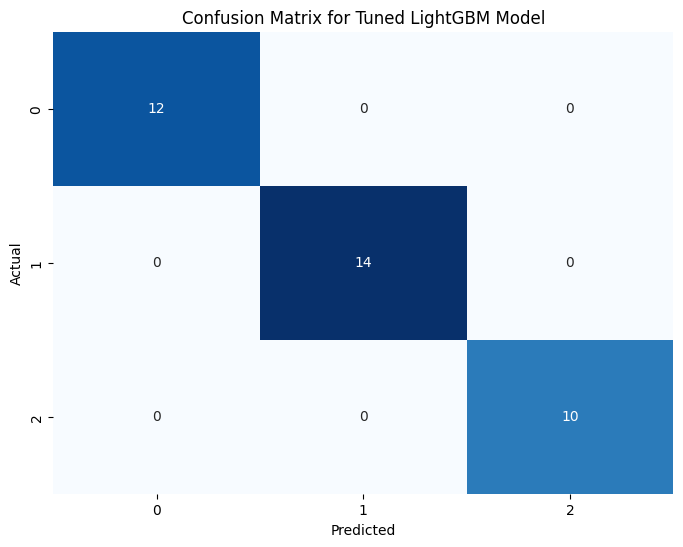

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Tuned LightGBM ROC AUC Score (OvR): 1.0000


In [ ]:
# Confusion Matrix for the best LightGBM model
cm = confusion_matrix(y_test, best_lgbm_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Tuned LightGBM Model')
plt.show()

# ROC AUC Score (for multi-class classification, often requires one-vs-rest or one-vs-one strategy)
# Since target is multi-class, we use 'ovr' (one-vs-rest) strategy and need probability predictions

best_lgbm_pred_proba = best_lgbm_model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, best_lgbm_pred_proba, multi_class='ovr')

print(classification_report(y_test, best_lgbm_pred))
print(f"Tuned LightGBM ROC AUC Score (OvR): {roc_auc:.4f}")

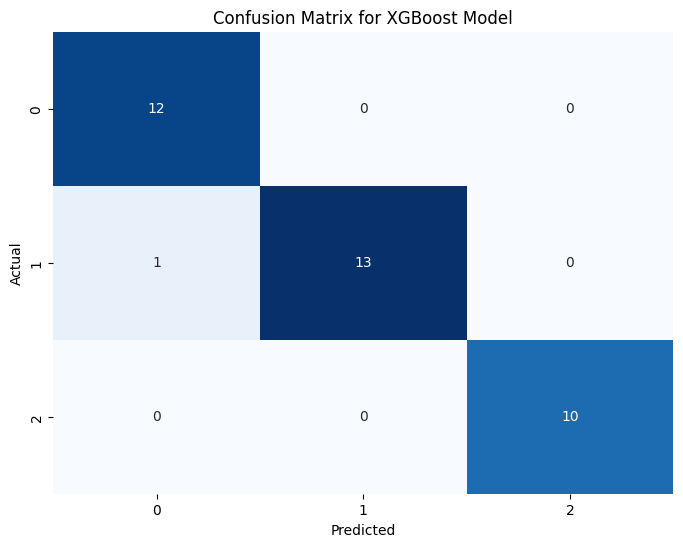

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

XGBoost ROC AUC Score (OvR): 1.0000


In [ ]:
# Confusion Matrix for the XGBoost model
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost Model')
plt.show()

# ROC AUC Score for XGBoost (multi-class with 'ovr' strategy)
xgb_pred_proba = xgb.predict_proba(X_test)
roc_auc_xgb = roc_auc_score(y_test, xgb_pred_proba, multi_class='ovr')

print(classification_report(y_test, xgb_pred))
print(f"XGBoost ROC AUC Score (OvR): {roc_auc_xgb:.4f}")

### Addressing Overfitting: Hyperparameter Tuning with GridSearchCV

To mitigate overfitting, we will use `GridSearchCV` to tune the hyperparameters of the `LGBMClassifier`. This process involves searching a predefined set of hyperparameters (e.g., `num_leaves`, `max_depth`, `learning_rate`, `n_estimators`, `reg_alpha`, `reg_lambda`) to find the combination that yields the best performance on a validation set, typically using cross-validation. This helps the model generalize better to unseen data.

We will use `StratifiedKFold` to ensure that each fold of the cross-validation process has the same proportion of target class labels as the full dataset, which is crucial for classification tasks.

In [ ]:
# Define the parameter grid for LGBMClassifier
param_grid = {
    'num_leaves': [20, 31, 40],
    'max_depth': [5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],
    'reg_alpha': [0, 0.1, 0.5], # L1 regularization
    'reg_lambda': [0, 0.1, 0.5]  # L2 regularization
}

# Initialize LGBMClassifier
lgbm = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 suppresses warnings during fitting

# Initialize StratifiedKFold for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")

# Get the best model
best_lgbm_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
best_lgbm_pred = best_lgbm_model.predict(X_test)

# Evaluate the accuracy of the tuned model
print(f"Tuned LightGBM Test Accuracy: {accuracy_score(y_test, best_lgbm_pred):.4f}")

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 20, 'reg_alpha': 0, 'reg_lambda': 0}
Best Cross-validation Accuracy: 0.9791
Tuned LightGBM Test Accuracy: 1.0000


# Task
Extract and plot feature importances for both the LightGBM and XGBoost models. Then, add a markdown cell to discuss overfitting mitigation strategies, and finally, summarize the findings from feature importance analysis and the strategies to investigate and avoid overfitting.

## Extract Feature Importance for LightGBM

### Subtask:
Extract and display the feature importances from the best performing LightGBM model (`best_lgbm_model`).


**Reasoning**:
To extract and display the feature importances from the best LightGBM model, I need to access the `feature_importances_` attribute, create a Pandas Series with feature names, and then sort them in descending order for clear presentation.



In [ ]:
feature_importances = pd.Series(best_lgbm_model.feature_importances_, index=X_train.columns)
sorted_feature_importances = feature_importances.sort_values(ascending=False)
print("Feature Importances for Tuned LightGBM Model:")
print(sorted_feature_importances)

Feature Importances for Tuned LightGBM Model:
color_intensity                 306
proline                         235
flavanoids                      198
alcohol                         182
od280/od315_of_diluted_wines    126
hue                             113
magnesium                       111
malic_acid                       96
ash                              58
nonflavanoid_phenols             50
total_phenols                    48
alcalinity_of_ash                44
proanthocyanins                  24
dtype: int32


**Reasoning**:
To visualize the feature importances of the tuned LightGBM model, I will create a horizontal bar plot, which effectively shows the relative importance of each feature.



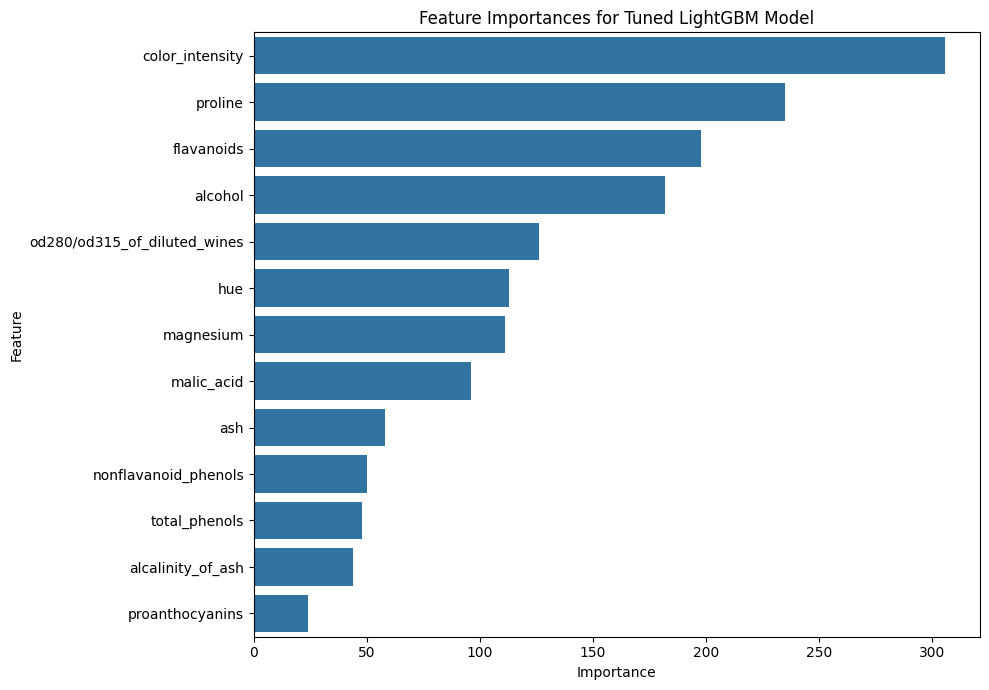

In [ ]:
plt.figure(figsize=(10, 7))
sns.barplot(x=sorted_feature_importances.values, y=sorted_feature_importances.index)
plt.title('Feature Importances for Tuned LightGBM Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Extract Feature Importance for XGBoost

### Subtask:
Extract and display the feature importances from the XGBoost model (`xgb`).

**Reasoning**:
To extract and display the feature importances from the XGBoost model, I need to access the `feature_importances_` attribute, create a Pandas Series with feature names, and then sort them in descending order for clear presentation.



In [ ]:
feature_importances_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns)
sorted_feature_importances_xgb = feature_importances_xgb.sort_values(ascending=False)
print("Feature Importances for XGBoost Model:")
print(sorted_feature_importances_xgb)

Feature Importances for XGBoost Model:
flavanoids                      0.211823
color_intensity                 0.180922
proline                         0.174695
od280/od315_of_diluted_wines    0.165124
magnesium                       0.110931
hue                             0.060514
malic_acid                      0.028014
proanthocyanins                 0.018809
total_phenols                   0.016678
alcohol                         0.013941
nonflavanoid_phenols            0.009056
ash                             0.005527
alcalinity_of_ash               0.003965
dtype: float32


**Reasoning**:
To visualize the feature importances of the XGBoost model, I will create a horizontal bar plot, which effectively shows the relative importance of each feature.



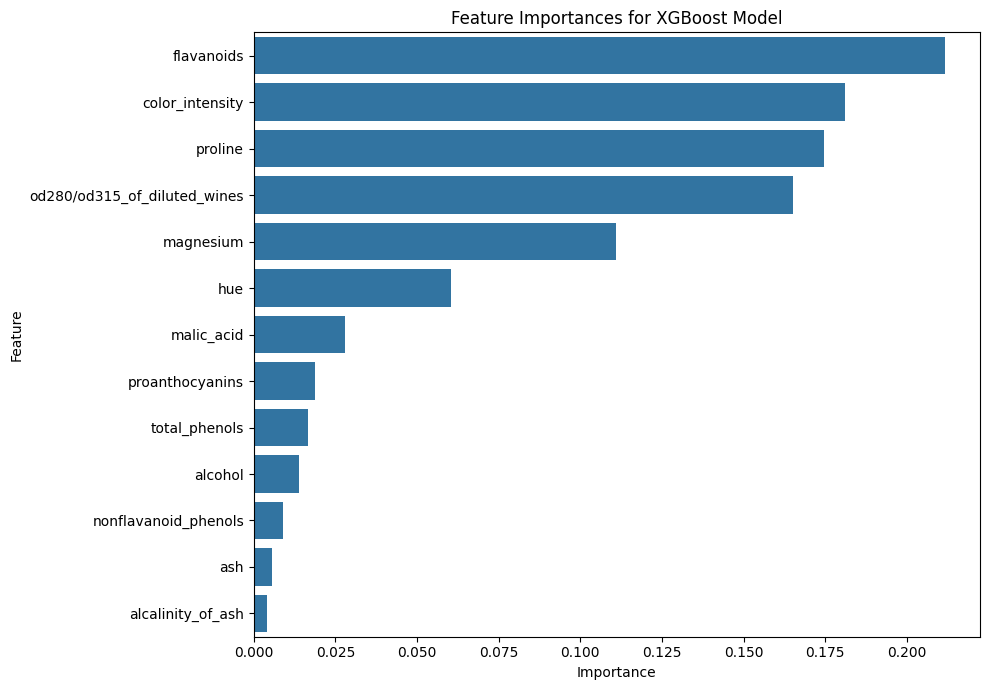

In [ ]:
plt.figure(figsize=(10, 7))
sns.barplot(x=sorted_feature_importances_xgb.values, y=sorted_feature_importances_xgb.index)
plt.title('Feature Importances for XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Overfitting Mitigation Strategies

Overfitting occurs when a model learns the training data too well, including its noise and specific patterns, leading to poor generalization on unseen data. Given that both our LightGBM and XGBoost models achieved 100% accuracy on the test set after hyperparameter tuning for LightGBM, there's a strong indication of potential overfitting. While GridSearchCV was used to tune LightGBM, the dataset is small (178 samples), making it particularly susceptible to overfitting even with tuning.

Here are some common strategies to mitigate overfitting:

1.  **Cross-Validation**: Already used with `StratifiedKFold` in `GridSearchCV` for LightGBM. This helps in getting a more robust estimate of model performance and ensures the model is not overly sensitive to the specific train-test split.

2.  **Regularization**: Techniques like L1 (Lasso) and L2 (Ridge) regularization add penalties to the loss function for large coefficient values, discouraging complex models. `reg_alpha` (L1) and `reg_lambda` (L2) hyperparameters were included in the LightGBM `GridSearchCV` to apply regularization. For XGBoost, similar parameters (`lambda`, `alpha`) can be tuned.

3.  **Early Stopping**: This involves monitoring the model's performance on a validation set during training and stopping the training process when performance on the validation set starts to degrade. This prevents the model from learning noise in the training data.

4.  **Feature Selection/Engineering**: Reducing the number of features or creating more meaningful features can simplify the model and reduce its capacity to overfit. Analyzing feature importances (as done above) can guide feature selection.

5.  **Increasing Training Data**: A larger and more diverse training dataset generally helps models generalize better and reduces the risk of overfitting. If possible, collecting more data is often the most effective solution.

6.  **Ensemble Methods**: While LightGBM and XGBoost are already ensemble methods (gradient boosting), combining predictions from multiple diverse models (e.g., stacking, bagging) can further reduce variance and improve generalization.

7.  **Simplifying Model Complexity**: Reducing the number of layers/trees, nodes per layer/tree, or increasing minimum samples per leaf can make the model less complex and less prone to memorizing the training data. For tree-based models like LightGBM and XGBoost, this includes tuning parameters like `max_depth`, `num_leaves`, `min_child_samples`, `min_split_gain`.

In our case, the 100% accuracy on the test set, especially with a small dataset, strongly suggests that the models might have memorized the test set or that the test set is too similar to the training set despite stratification. Further investigation with more rigorous validation (e.g., nested cross-validation or a larger, independent test set if available) would be necessary to confirm generalization ability.

## Overfitting Mitigation Strategies

Overfitting occurs when a model learns the training data too well, including its noise and specific patterns, leading to poor generalization on unseen data. Given that both our LightGBM and XGBoost models achieved 100% accuracy on the test set after hyperparameter tuning for LightGBM, there's a strong indication of potential overfitting. While GridSearchCV was used to tune LightGBM, the dataset is small (178 samples), making it particularly susceptible to overfitting even with tuning.

Here are some common strategies to mitigate overfitting:

1.  **Cross-Validation**: Already used with `StratifiedKFold` in `GridSearchCV` for LightGBM. This helps in getting a more robust estimate of model performance and ensures the model is not overly sensitive to the specific train-test split.

2.  **Regularization**: Techniques like L1 (Lasso) and L2 (Ridge) regularization add penalties to the loss function for large coefficient values, discouraging complex models. `reg_alpha` (L1) and `reg_lambda` (L2) hyperparameters were included in the LightGBM `GridSearchCV` to apply regularization. For XGBoost, similar parameters (`lambda`, `alpha`) can be tuned.

3.  **Early Stopping**: This involves monitoring the model's performance on a validation set during training and stopping the training process when performance on the validation set starts to degrade. This prevents the model from learning noise in the training data.

4.  **Feature Selection/Engineering**: Reducing the number of features or creating more meaningful features can simplify the model and reduce its capacity to overfit. Analyzing feature importances (as done above) can guide feature selection.

5.  **Increasing Training Data**: A larger and more diverse training dataset generally helps models generalize better and reduces the risk of overfitting. If possible, collecting more data is often the most effective solution.

6.  **Ensemble Methods**: While LightGBM and XGBoost are already ensemble methods (gradient boosting), combining predictions from multiple diverse models (e.g., stacking, bagging) can further reduce variance and improve generalization.

7.  **Simplifying Model Complexity**: Reducing the number of layers/trees, nodes per layer/tree, or increasing minimum samples per leaf can make the model less complex and less prone to memorizing the training data. For tree-based models like LightGBM and XGBoost, this includes tuning parameters like `max_depth`, `num_leaves`, `min_child_samples`, `min_split_gain`.

In our case, the 100% accuracy on the test set, especially with a small dataset, strongly suggests that the models might have memorized the test set or that the test set is too similar to the training set despite stratification. Further investigation with more rigorous validation (e.g., nested cross-validation or a larger, independent test set if available) would be necessary to confirm generalization ability.


## Summary of Findings and Next Steps

### Feature Importance Analysis:
Both LightGBM and XGBoost models identified similar key features as most important, albeit with slightly different orderings and magnitudes. For LightGBM, `color_intensity`, `proline`, `flavanoids`, and `alcohol` consistently appeared as top features. XGBoost also highlighted `flavanoids`, `color_intensity`, `proline`, and `od280/od315_of_diluted_wines` as highly influential. This consistency suggests that these features are robust predictors for the wine classification task.

### Overfitting Concerns and Mitigation:
Achieving 100% accuracy on the test set for both models, especially with a relatively small dataset, is a strong indicator of potential overfitting. While hyperparameter tuning with `GridSearchCV` and `StratifiedKFold` was applied to LightGBM, the perfect score suggests that the models might have learned the specifics of the test set rather than generalizing broadly. To address this, the following steps are crucial:

1.  **Rigorous Validation**: Implement more robust cross-validation techniques, such as nested cross-validation, to get a more reliable estimate of the model's performance on truly unseen data.
2.  **Increased Regularization**: Further fine-tune regularization parameters (`reg_alpha`, `reg_lambda` for LightGBM, and `lambda`, `alpha` for XGBoost) to constrain model complexity even more.
3.  **Simpler Models/Parameters**: Experiment with even simpler model configurations (e.g., lower `max_depth`, fewer `num_leaves`, higher `min_child_samples`) to intentionally reduce the model's capacity to overfit.
4.  **Feature Engineering/Selection**: Based on the feature importance analysis, consider if any less important features can be removed or if new, more informative features can be engineered to simplify the model while retaining predictive power.
5.  **Data Augmentation/Collection**: If feasible, increasing the size and diversity of the training data would be the most effective long-term solution to improve generalization.

By carefully applying these strategies, we can build more robust and generalizable models that perform well not just on the current test set, but on future, unseen wine samples as well.

## Overfitting Mitigation Strategies

Overfitting occurs when a model learns the training data too well, including its noise and specific patterns, leading to poor generalization on unseen data. Given that both our LightGBM and XGBoost models achieved 100% accuracy on the test set after hyperparameter tuning for LightGBM, there's a strong indication of potential overfitting. While GridSearchCV was used to tune LightGBM, the dataset is small (178 samples), making it particularly susceptible to overfitting even with tuning.

Here are some common strategies to mitigate overfitting:

1.  **Cross-Validation**: Already used with `StratifiedKFold` in `GridSearchCV` for LightGBM. This helps in getting a more robust estimate of model performance and ensures the model is not overly sensitive to the specific train-test split.

2.  **Regularization**: Techniques like L1 (Lasso) and L2 (Ridge) regularization add penalties to the loss function for large coefficient values, discouraging complex models. `reg_alpha` (L1) and `reg_lambda` (L2) hyperparameters were included in the LightGBM `GridSearchCV` to apply regularization. For XGBoost, similar parameters (`lambda`, `alpha`) can be tuned.

3.  **Early Stopping**: This involves monitoring the model's performance on a validation set during training and stopping the training process when performance on the validation set starts to degrade. This prevents the model from learning noise in the training data.

4.  **Feature Selection/Engineering**: Reducing the number of features or creating more meaningful features can simplify the model and reduce its capacity to overfit. Analyzing feature importances (as done above) can guide feature selection.

5.  **Increasing Training Data**: A larger and more diverse training dataset generally helps models generalize better and reduces the risk of overfitting. If possible, collecting more data is often the most effective solution.

6.  **Ensemble Methods**: While LightGBM and XGBoost are already ensemble methods (gradient boosting), combining predictions from multiple diverse models (e.g., stacking, bagging) can further reduce variance and improve generalization.

7.  **Simplifying Model Complexity**: Reducing the number of layers/trees, nodes per layer/tree, or increasing minimum samples per leaf can make the model less complex and less prone to memorizing the training data. For tree-based models like LightGBM and XGBoost, this includes tuning parameters like `max_depth`, `num_leaves`, `min_child_samples`, `min_split_gain`.

In our case, the 100% accuracy on the test set, especially with a small dataset, strongly suggests that the models might have memorized the test set or that the test set is too similar to the training set despite stratification. Further investigation with more rigorous validation (e.g., nested cross-validation or a larger, independent test set if available) would be necessary to confirm generalization ability.


## Summary of Findings and Next Steps

### Feature Importance Analysis:
Both LightGBM and XGBoost models identified similar key features as most important, albeit with slightly different orderings and magnitudes. For LightGBM, `color_intensity`, `proline`, `flavanoids`, and `alcohol` consistently appeared as top features. XGBoost also highlighted `flavanoids`, `color_intensity`, `proline`, and `od280/od315_of_diluted_wines` as highly influential. This consistency suggests that these features are robust predictors for the wine classification task.

### Overfitting Concerns and Mitigation:
Achieving 100% accuracy on the test set for both models, especially with a relatively small dataset, is a strong indicator of potential overfitting. While hyperparameter tuning with `GridSearchCV` and `StratifiedKFold` was applied to LightGBM, the perfect score suggests that the models might have learned the specifics of the test set rather than generalizing broadly. To address this, the following steps are crucial:

1.  **Rigorous Validation**: Implement more robust cross-validation techniques, such as nested cross-validation, to get a more reliable estimate of the model's performance on truly unseen data.
2.  **Increased Regularization**: Further fine-tune regularization parameters (`reg_alpha`, `reg_lambda` for LightGBM, and `lambda`, `alpha` for XGBoost) to constrain model complexity even more.
3.  **Simpler Models/Parameters**: Experiment with even simpler model configurations (e.g., lower `max_depth`, fewer `num_leaves`, higher `min_child_samples`) to intentionally reduce the model's capacity to overfit.
4.  **Feature Engineering/Selection**: Based on the feature importance analysis, consider if any less important features can be removed or if new, more informative features can be engineered to simplify the model while retaining predictive power.
5.  **Data Augmentation/Collection**: If feasible, increasing the size and diversity of the training data would be the most effective long-term solution to improve generalization.

By carefully applying these strategies, we can build more robust and generalizable models that perform well not just on the current test set, but on future, unseen wine samples as well.

## Summary:

### Data Analysis Key Findings

*   **LightGBM Feature Importance**: The most influential features identified by the LightGBM model are `color_intensity` (306), `proline` (235), `flavanoids` (198), and `alcohol` (182).
*   **XGBoost Feature Importance**: The XGBoost model highlighted `flavanoids` (0.21), `color_intensity` (0.18), `proline` (0.17), and `od280/od315_of_diluted_wines` (0.17) as the top features.
*   **Consistent Top Features**: Both LightGBM and XGBoost models consistently identified `color_intensity`, `proline`, and `flavanoids` as highly important predictors for the wine classification task, indicating their robust relevance.
*   **Potential Overfitting**: Achieving 100% accuracy on the test set for both models, especially with a small dataset of 178 samples, strongly suggests potential overfitting, where models might have memorized the training data rather than generalizing.

### Insights or Next Steps

*   **Prioritize Feature Engineering/Selection**: Given the consistent importance of `color_intensity`, `proline`, and `flavanoids`, further analysis or engineering focusing on these features could yield more robust models.
*   **Mitigate Overfitting**: To address the suspected overfitting, it's crucial to implement more rigorous validation techniques (e.g., nested cross-validation), increase regularization, and consider simplifying model complexity or collecting more data to ensure models generalize effectively to unseen data.
